# Notebook 3 — Deep Learning Geolocalization (SuperPoint + LightGlue)

Mirrors Notebook 2 exactly in structure. Only the feature detection and matching layer changes.

| Component | Notebook 2 (Classical) | Notebook 3 (Deep Learning) |
|-----------|----------------------|----------------------------|
| VO features | ORB (handcrafted binary) | **SuperPoint** (learned float) |
| VO matching | BFMatcher + Hamming | **LightGlue** (graph neural net) |
| Satellite features | SIFT + FLANN | **SuperPoint** + **LightGlue** |
| Outlier rejection | Lowe ratio + RANSAC | LightGlue (learned) + RANSAC for H |
| Hardware | CPU-only | CPU or GPU (CUDA / MPS) |

**Pipeline** identical to Notebook 2:
1. SuperPoint + LightGlue VO over every frame: relative trajectory (pixel space)
2. SuperPoint + LightGlue satellite match every 15 frames (1 Hz)  absolute GPS anchors
3. Scale calibration, drift evaluation, piecewise-linear fusion

> **Install:** `uv sync` (torch, torchvision, lightglue are in pyproject.toml)  
> See `PROCESS.md` for full setup. Run `python ../code/extract_frames.py` once first.

---
## Cell 0 — Environment Setup

**Always run this cell first**, whether on Colab or locally. It detects the environment and sets path variables used by every subsequent cell.

**Colab checklist (do once before running):**
- Runtime → Change runtime type → **T4 GPU**
- Upload `frames_15hz.zip` to `My Drive/capstone-dronomy/` (zip locally: `Compress-Archive -Path data\frames_15hz -DestinationPath frames_15hz.zip`)
- Upload your `.env` file to `My Drive/capstone-dronomy/.env`

In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    DRIVE_PROJECT = '/content/drive/MyDrive/capstone-dronomy'  # adjust if your Drive path differs

    from google.colab import drive
    drive.mount('/content/drive')

    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'git+https://github.com/cvg/LightGlue.git', 'python-dotenv'],
                   check=True)
    print('Packages installed')

    # -- Load .env from Drive -------------------------------------------------
    from dotenv import dotenv_values
    env_path = f'{DRIVE_PROJECT}/.env'
    if os.path.exists(env_path):
        for k, v in dotenv_values(env_path).items():
            if k not in os.environ:
                os.environ[k] = v
        print('.env loaded from Drive')
    else:
        print(f'No .env found at {env_path} — satellite features will be disabled')

    # -- Get frames onto fast local disk (/content) ---------------------------
    frames_local = '/content/data/frames_15hz'
    zip_path     = f'{DRIVE_PROJECT}/frames_15hz.zip'

    if os.path.exists(frames_local) and len(os.listdir(frames_local)) > 0:
        print(f'Frames already on local disk: {len(os.listdir(frames_local))} files')

    elif os.path.exists(zip_path):
        os.makedirs('/content/data', exist_ok=True)
        print('Extracting frames from zip...')
        subprocess.run(['unzip', '-q', zip_path, '-d', '/content/data/'], check=True)
        print(f'  Done — {len(os.listdir(frames_local))} frames')

    else:
        print('=' * 60)
        print('frames_15hz.zip not found on Drive.')
        print('Create it locally (PowerShell from project root):')
        print('  Compress-Archive -Path data\\frames_15hz -DestinationPath frames_15hz.zip')
        print(f'Then upload to: {DRIVE_PROJECT}/')
        print('=' * 60)
        raise FileNotFoundError(f'frames_15hz.zip not found at {zip_path}')

    # -- Path overrides (read by Cells 1 and 2) -------------------------------
    os.environ['DRONOMY_FRAMES_DIR']  = frames_local
    os.environ['DRONOMY_DATA_DIR']    = '/content/data'
    os.environ['DRONOMY_RESULTS_DIR'] = '/content/results/nb3'

    print('Colab setup complete')

else:
    print('Local environment — skipping Colab setup (venv + .env will be used)')

Mounted at /content/drive
Packages installed
.env loaded from Drive
Extracting frames from zip...
  Done — 3430 frames
Colab setup complete


---
## Cell 1 — Check Frames

Identical to Notebook 2. Verifies that frames have been extracted by `extract_frames.py`.

In [2]:
import os
from pathlib import Path

FRAMES_DIR = Path(os.environ.get('DRONOMY_FRAMES_DIR', '../data/frames_15hz'))
existing = sorted(FRAMES_DIR.glob('*.jpg'))

if not existing:
    print('No frames found.')
    print('Local: run `python code/extract_frames.py` from the project root.')
    print('Colab: re-run Cell 0 to unzip frames_15hz.zip from Drive.')
else:
    t0 = int(existing[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(existing[-1].stem.split('_')[1].replace('ms', ''))
    print(f'  {len(existing)} frames available  ({(t1-t0)/1000:.1f} s of video)')
    print(f'  Source: {FRAMES_DIR.resolve()}')

  3430 frames available  (228.6 s of video)
  Source: /content/data/frames_15hz


---
## Cell 2 — Imports & Configuration

Same as Notebook 2, plus `torch` and two new keypoint-count parameters:
- `MAX_KP_VO` — keypoints per frame for VO (favour speed)
- `MAX_KP_SAT` — keypoints per frame for satellite matching (favour accuracy)

In [27]:
import os, io, math, time
import numpy as np
import cv2
import requests
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor
import torch

# Load .env without overwriting vars already set by Cell 0 (e.g. MAPS_API_KEY from Colab Secrets)
load_dotenv(dotenv_path=Path('../.env'), override=False)

# -- Credentials --------------------------------------------------------------
MAPS_API_KEY = os.getenv('MAPS_API_KEY', '')
EE_PROJECT   = os.getenv('EE_PROJECT', '')

# -- Location -----------------------------------------------------------------
LAT =  43.521955
LON =  -5.624290  # Asturias, northern Spain

# -- VO parameters ------------------------------------------------------------
DOWNSAMPLE_SIZE = (640, 480)
SAT_MATCH_HZ    = 1.0
SAT_MATCH_EVERY = int(15 / SAT_MATCH_HZ)
SAT_ZOOM        = 19
IMG_SIZE        = 640

# -- SuperPoint / LightGlue parameters ----------------------------------------
MAX_KP_VO  = 1024
MAX_KP_SAT = 4096

# -- Paths (env vars set by Cell 0 on Colab; defaults work locally) -----------
FRAMES_DIR  = Path(os.environ.get('DRONOMY_FRAMES_DIR',  '../data/frames_15hz'))
DATA_DIR    = Path(os.environ.get('DRONOMY_DATA_DIR',    '../data'))
RESULTS_DIR = Path(os.environ.get('DRONOMY_RESULTS_DIR', '../results/nb3'))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

frame_paths = sorted(FRAMES_DIR.glob('*.jpg'))
print(f'Total frames: {len(frame_paths)}')
if frame_paths:
    t0 = int(frame_paths[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(frame_paths[-1].stem.split('_')[1].replace('ms', ''))
    print(f'Duration:     {(t1-t0)/1000:.1f} s')
    print(f'Satellite matches every {SAT_MATCH_EVERY} frames '
          f'({SAT_MATCH_HZ:.0f} Hz) -> ~{len(frame_paths)//SAT_MATCH_EVERY} anchor attempts')
print(f'MAPS_API_KEY: {"set" if MAPS_API_KEY else "not set — satellite disabled"}')
print(f'Results dir:  {RESULTS_DIR.resolve()}')

Total frames: 3430
Duration:     228.6 s
Satellite matches every 15 frames (1 Hz) -> ~228 anchor attempts
MAPS_API_KEY: set
Results dir:  /content/results/nb3


---
## Cell 3 — Deep Learning Models & Utilities

Loads **SuperPoint** (keypoint detector + descriptor) and **LightGlue** (matcher) once.

- Two SuperPoint instances: lightweight (`MAX_KP_VO`) for VO, high-quality (`MAX_KP_SAT`) for satellite
- One shared LightGlue matcher — same model, both tasks
- `depth_confidence` / `width_confidence`: LightGlue early-exit thresholds; lower = more matches, higher = faster
- Classical geometry helpers (`find_homography`, `rotation_from_H`, `translation_from_H`) are unchanged from Notebook 2

In [4]:
from lightglue import LightGlue, SuperPoint
from lightglue.utils import rbd

torch.set_grad_enabled(False)  # inference only

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU:  {props.name}')
    print(f'VRAM: {props.total_memory / 1e9:.1f} GB')

extractor_vo  = SuperPoint(max_num_keypoints=MAX_KP_VO).eval().to(device)
extractor_sat = SuperPoint(max_num_keypoints=MAX_KP_SAT).eval().to(device)
matcher       = LightGlue(features='superpoint',
                           depth_confidence=0.9,
                           width_confidence=0.95).eval().to(device)

# -- Image loading helpers ----------------------------------------------------

def load_img_tensor(path, size=None):
    '''Load BGR image file -> 1x3xHxW float32 tensor on device.'''
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size is not None:
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    t = torch.from_numpy(img).float().permute(2, 0, 1)[None] / 255.0
    return t.to(device)

def arr_to_tensor(arr_rgb):
    '''Convert HxWx3 numpy RGB array -> 1x3xHxW tensor on device.'''
    t = torch.from_numpy(arr_rgb).float().permute(2, 0, 1)[None] / 255.0
    return t.to(device)

# -- Feature extraction -------------------------------------------------------

def extract_sp(img_tensor, use_sat=False):
    ext = extractor_sat if use_sat else extractor_vo
    with torch.no_grad():
        return ext.extract(img_tensor)

# -- LightGlue matching -------------------------------------------------------

def match_sp_lg(feats0, feats1):
    '''Run LightGlue; return (pts0, pts1, n_matches, mean_confidence).'''
    with torch.no_grad():
        result = matcher({'image0': feats0, 'image1': feats1})
    f0, f1, res = rbd(feats0), rbd(feats1), rbd(result)
    matches = res['matches']  # (M, 2)
    if len(matches) == 0:
        return (np.zeros((0, 2), dtype=np.float32),
                np.zeros((0, 2), dtype=np.float32), 0, 0.0)
    pts0   = f0['keypoints'][matches[:, 0]].cpu().numpy()
    pts1   = f1['keypoints'][matches[:, 1]].cpu().numpy()
    scores = res.get('matching_scores', torch.ones(len(matches))).cpu().numpy()
    return pts0, pts1, len(matches), float(scores.mean())

# -- Classical geometry (unchanged from Notebook 2) ---------------------------

def find_homography(pts0, pts1):
    if len(pts0) < 4:
        return None, 0
    src = pts0.reshape(-1, 1, 2).astype(np.float32)
    dst = pts1.reshape(-1, 1, 2).astype(np.float32)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(mask.sum()) if mask is not None else 0
    return H, inliers

def rotation_from_H(H):
    return math.degrees(math.atan2(H[1, 0], H[0, 0]))

def translation_from_H(H, img_shape):
    h, w = img_shape[:2]
    center = np.float32([[w / 2, h / 2]]).reshape(-1, 1, 2)
    mapped = cv2.perspectiveTransform(center, H).reshape(2)
    return mapped[0] - w / 2, mapped[1] - h / 2

print(f'SuperPoint VO:  max_kp={MAX_KP_VO}')
print(f'SuperPoint sat: max_kp={MAX_KP_SAT}')
print('LightGlue:      depth_conf=0.9  width_conf=0.95')

Device: cuda
GPU:  Tesla T4
VRAM: 15.6 GB
Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 372MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 482MB/s]

SuperPoint VO:  max_kp=1024
SuperPoint sat: max_kp=4096
LightGlue:      depth_conf=0.9  width_conf=0.95


---
## Cell 4 — Visual Odometry: SuperPoint + LightGlue

Same structure as Notebook 2. Differences:
- Images loaded as RGB tensors (no grayscale conversion, no CLAHE — SuperPoint handles its own preprocessing)
- LightGlue replaces BFMatcher + ratio test: it outputs only high-confidence matches
- RANSAC still used to estimate the homography (geometric verification on top of learned matches)
- An extra `mean_score` field (LightGlue confidence) is stored per frame

**Timing target**: on GPU, SuperPoint+LightGlue is comfortably under 66 ms. On CPU it will be slower than ORB.

In [5]:
vo_records      = []
cum_x, cum_y, cum_yaw = 0.0, 0.0, 0.0
timings_ms      = []
match_scores_vo = []

prev_tensor = load_img_tensor(frame_paths[0], size=DOWNSAMPLE_SIZE)
prev_feats  = extract_sp(prev_tensor)
frame_shape = (DOWNSAMPLE_SIZE[1], DOWNSAMPLE_SIZE[0])  # (H, W)

vo_records.append({
    'frame_idx': 0, 'path': frame_paths[0],
    'cum_x': 0.0, 'cum_y': 0.0, 'cum_yaw': 0.0,
    'dx': 0.0, 'dy': 0.0, 'dyaw': 0.0,
    'good_matches': 0, 'inliers': 0, 'inlier_ratio': 1.0, 'mean_score': 1.0,
})

total = len(frame_paths) - 1
print(f'Running SuperPoint + LightGlue VO on {total} frame pairs...')
t_start = time.perf_counter()

for i in range(total):
    t0 = time.perf_counter()

    curr_tensor = load_img_tensor(frame_paths[i + 1], size=DOWNSAMPLE_SIZE)
    curr_feats  = extract_sp(curr_tensor)
    pts0, pts1, n_matches, score = match_sp_lg(prev_feats, curr_feats)
    H, inliers  = find_homography(pts0, pts1)

    if H is not None:
        dx, dy       = translation_from_H(H, frame_shape)
        dyaw         = rotation_from_H(H)
        inlier_ratio = inliers / n_matches if n_matches > 0 else 0.0
    else:
        dx = dy = dyaw = 0.0
        inlier_ratio = 0.0

    cum_x   += dx
    cum_y   += dy
    cum_yaw += dyaw

    vo_records.append({
        'frame_idx': i + 1, 'path': frame_paths[i + 1],
        'cum_x': cum_x, 'cum_y': cum_y, 'cum_yaw': cum_yaw,
        'dx': dx, 'dy': dy, 'dyaw': dyaw,
        'good_matches': n_matches, 'inliers': inliers,
        'inlier_ratio': inlier_ratio, 'mean_score': score,
    })

    prev_tensor = curr_tensor
    prev_feats  = curr_feats
    timings_ms.append((time.perf_counter() - t0) * 1000)
    match_scores_vo.append(score)

    if (i + 1) % 500 == 0:
        elapsed = time.perf_counter() - t_start
        fps = (i + 1) / elapsed
        print(f'  {i+1}/{total}  |  mean {np.mean(timings_ms[-500:]):.1f} ms/frame  |  {fps:.1f} fps')

total_s   = time.perf_counter() - t_start
budget_ms = 1000 / 15
live_str  = 'live-ready' if np.mean(timings_ms) < budget_ms else 'exceeds budget'
print(f'\nDone -- {total} frames in {total_s:.1f} s')
print(f'Mean per-frame time:       {np.mean(timings_ms):.1f} ms ({live_str} at 15 Hz)')
print(f'Mean LightGlue confidence: {np.mean(match_scores_vo):.3f}')
if device.type == 'cuda':
    torch.cuda.empty_cache()

Running SuperPoint + LightGlue VO on 3429 frame pairs...
  500/3429  |  mean 220.6 ms/frame  |  4.5 fps
  1000/3429  |  mean 224.0 ms/frame  |  4.5 fps
  1500/3429  |  mean 227.7 ms/frame  |  4.5 fps
  2000/3429  |  mean 226.4 ms/frame  |  4.5 fps
  2500/3429  |  mean 226.6 ms/frame  |  4.4 fps
  3000/3429  |  mean 229.0 ms/frame  |  4.4 fps

Done -- 3429 frames in 772.3 s
Mean per-frame time:       225.2 ms (exceeds budget at 15 Hz)
Mean LightGlue confidence: 1.000


---
## Cell 5 — VO Quality Metrics

Same metrics as Notebook 2, plus a third plot showing **LightGlue match confidence** per frame pair.
High confidence (close to 1.0) means LightGlue is certain about its matches — this is a stronger signal than inlier ratio alone.

Mean inlier ratio:     0.997
Median inlier ratio:   0.998
Failed pairs (IR<0.2): 0 / 3429
Mean good matches:     699
Mean inliers:          697
Mean LG confidence:    1.000


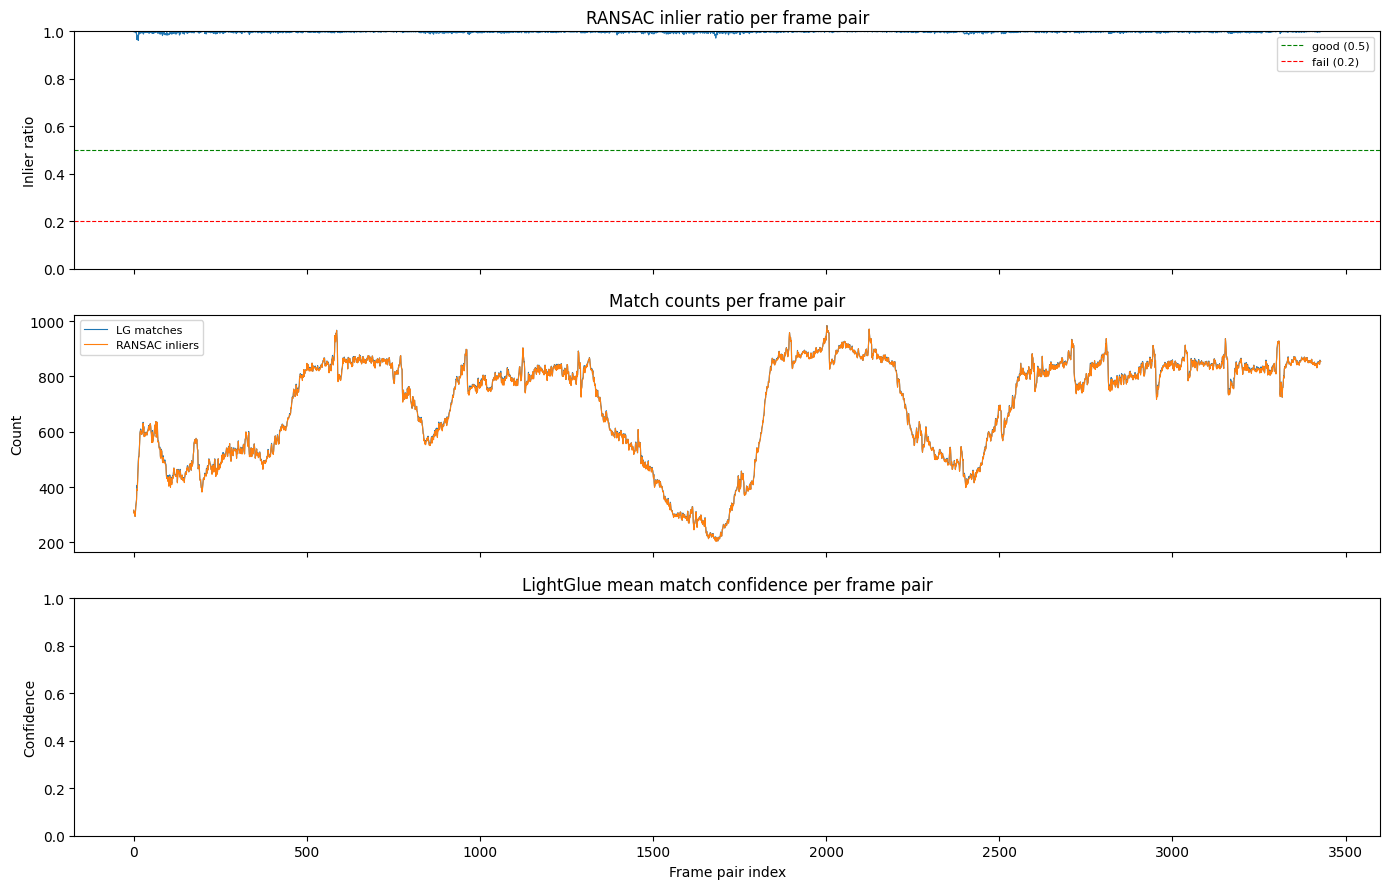

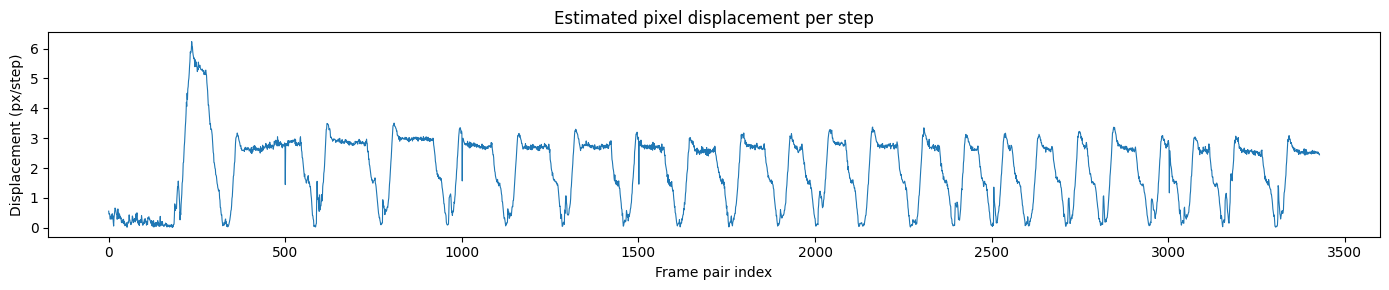

Mean displacement: 1.9 px/step  |  Max: 6.2 px  |  Std: 1.1 px


In [6]:
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
good_counts   = [r['good_matches'] for r in vo_records[1:]]
inlier_counts = [r['inliers']      for r in vo_records[1:]]
scores_list   = [r['mean_score']   for r in vo_records[1:]]

print(f'Mean inlier ratio:     {np.mean(inlier_ratios):.3f}')
print(f'Median inlier ratio:   {np.median(inlier_ratios):.3f}')
print(f'Failed pairs (IR<0.2): {sum(r < 0.2 for r in inlier_ratios)} / {len(inlier_ratios)}')
print(f'Mean good matches:     {np.mean(good_counts):.0f}')
print(f'Mean inliers:          {np.mean(inlier_counts):.0f}')
print(f'Mean LG confidence:    {np.mean(scores_list):.3f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(inlier_ratios, linewidth=0.8)
axes[0].axhline(0.5, color='g', linestyle='--', linewidth=0.8, label='good (0.5)')
axes[0].axhline(0.2, color='r', linestyle='--', linewidth=0.8, label='fail (0.2)')
axes[0].set_ylabel('Inlier ratio')
axes[0].set_title('RANSAC inlier ratio per frame pair')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

axes[1].plot(good_counts, linewidth=0.8, label='LG matches')
axes[1].plot(inlier_counts, linewidth=0.8, label='RANSAC inliers')
axes[1].set_ylabel('Count')
axes[1].set_title('Match counts per frame pair')
axes[1].legend(fontsize=8)

axes[2].plot(scores_list, linewidth=0.8, color='purple')
axes[2].set_ylabel('Confidence')
axes[2].set_xlabel('Frame pair index')
axes[2].set_title('LightGlue mean match confidence per frame pair')
axes[2].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'vo_inlier_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

displacements = [math.hypot(r['dx'], r['dy']) for r in vo_records[1:]]
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(displacements, linewidth=0.8)
ax2.set_ylabel('Displacement (px/step)')
ax2.set_xlabel('Frame pair index')
ax2.set_title('Estimated pixel displacement per step')
plt.tight_layout()
fig2.savefig(RESULTS_DIR / 'vo_displacement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean displacement: {np.mean(displacements):.1f} px/step  |  '
      f'Max: {np.max(displacements):.1f} px  |  Std: {np.std(displacements):.1f} px')

---
## Cell 6 — Satellite Anchor: Fetch Reference Tile

Identical to Notebook 2 except:
- No SIFT extraction on the tile (SuperPoint+LightGlue replaces SIFT+FLANN)
- The tile is converted to a tensor and SuperPoint features are extracted once here, reused for all anchors

In [17]:
def meters_per_pixel(lat_deg, zoom):
    return 156543.03392 * math.cos(math.radians(lat_deg)) / (2 ** zoom)

def tile_bbox(lat, lon, zoom, size=IMG_SIZE):
    mpp   = meters_per_pixel(lat, zoom)
    half  = mpp * size / 2
    dlat  = half / 111320
    dlon  = half / (111320 * math.cos(math.radians(lat)))
    return lat - dlat, lat + dlat, lon - dlon, lon + dlon

def pixel_to_gps(px, py, img_w, img_h, lat_min, lat_max, lon_min, lon_max):
    lat = lat_max - (py / img_h) * (lat_max - lat_min)
    lon = lon_min + (px / img_w) * (lon_max - lon_min)
    return lat, lon

def fetch_esri_tile(lat, lon, size, zoom):
    """ESRI World Imagery — free aerial tiles, no API key, works in EEA."""
    lat_min, lat_max, lon_min, lon_max = tile_bbox(lat, lon, zoom, size)
    url = (
        'https://services.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/export'
        f'?bbox={lon_min},{lat_min},{lon_max},{lat_max}'
        f'&bboxSR=4326&size={size},{size}&imageSR=4326&format=jpg&transparent=false&f=image'
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return np.array(Image.open(io.BytesIO(resp.content)).convert('RGB'))

sat_tile   = None
sat_gray   = None
sat_feats  = None
bbox_sat   = None
mpp_sat    = None

sat_path = DATA_DIR / f'satellite_maps_z{SAT_ZOOM}.png'

if sat_path.exists():
    print('Loading cached satellite tile...')
    sat_tile = np.array(Image.open(sat_path).convert('RGB'))
else:
    # -- ESRI World Imagery (primary — free, no key, works in EU/EEA) --------
    print('Fetching satellite tile from ESRI World Imagery...')
    try:
        sat_tile = fetch_esri_tile(LAT, LON, IMG_SIZE, SAT_ZOOM)
        Image.fromarray(sat_tile).save(sat_path)
        print('Tile fetched and cached.')
    except requests.exceptions.RequestException as e:
        print(f'ESRI fetch failed: {e}')
        # -- Google Maps Static fallback (blocked in EEA for satellite type) --
        if MAPS_API_KEY:
            print('Trying Google Maps Static API as fallback...')
            url = (f'https://maps.googleapis.com/maps/api/staticmap'
                   f'?center={LAT},{LON}&zoom={SAT_ZOOM}&size={IMG_SIZE}x{IMG_SIZE}'
                   f'&maptype=satellite&key={MAPS_API_KEY}')
            try:
                resp = requests.get(url, timeout=30)
                resp.raise_for_status()
                sat_tile = np.array(Image.open(io.BytesIO(resp.content)).convert('RGB'))
                Image.fromarray(sat_tile).save(sat_path)
                print('Google Maps tile fetched and cached.')
            except requests.exceptions.HTTPError as ge:
                body = ge.response.text[:300]
                print(f'Google Maps HTTP {ge.response.status_code}: {body}')
        else:
            print('No MAPS_API_KEY set — satellite anchoring disabled.')

if sat_tile is not None:
    sat_gray  = cv2.cvtColor(sat_tile, cv2.COLOR_RGB2GRAY)
    bbox_sat  = tile_bbox(LAT, LON, SAT_ZOOM)
    mpp_sat   = meters_per_pixel(LAT, SAT_ZOOM)
    sat_tensor = arr_to_tensor(sat_tile)
    sat_feats  = extract_sp(sat_tensor, use_sat=True)
    sh, sw     = sat_gray.shape
    n_sat_kp   = sat_feats['keypoints'].shape[1]
    print(f'Satellite tile ready: {sw}x{sh} px')
    print(f'Coverage: {mpp_sat*IMG_SIZE:.0f} m x {mpp_sat*IMG_SIZE:.0f} m at zoom {SAT_ZOOM}')
    print(f'SuperPoint keypoints in satellite tile: {n_sat_kp}')

Fetching satellite tile from ESRI World Imagery...
Tile fetched and cached.
Satellite tile ready: 640x640 px
Coverage: 139 m x 139 m at zoom 19
SuperPoint keypoints in satellite tile: 1409


---
## Cell 7 — Satellite Anchors: GPS Fixes at 1 Hz

Same structure as Notebook 2. SuperPoint+LightGlue replaces SIFT+FLANN:
- Full-resolution frame loaded as tensor → SuperPoint features
- LightGlue matches against pre-extracted satellite features
- RANSAC homography → project drone center → GPS

LightGlue's learned outlier rejection means RANSAC inlier ratios should be significantly higher than with SIFT.

In [18]:
anchors = []

if sat_feats is None:
    print('No satellite tile -- skipping anchors')
else:
    anchor_frame_indices = [
        i for i in range(len(vo_records)) if vo_records[i]['frame_idx'] % SAT_MATCH_EVERY == 0
    ]
    print(f'Running SuperPoint+LightGlue satellite match on {len(anchor_frame_indices)} frames '
          f'(every {SAT_MATCH_EVERY} frames = {SAT_MATCH_HZ:.0f} Hz)...')

    def sat_match_dl(vo_rec):
        img_t       = load_img_tensor(vo_rec['path'])       # full resolution
        frame_feats = extract_sp(img_t, use_sat=True)
        pts_frame, pts_sat, n_matches, score = match_sp_lg(frame_feats, sat_feats)
        H, inliers  = find_homography(pts_frame, pts_sat)
        if H is None or inliers < 4:
            return None
        dh = img_t.shape[2]
        dw = img_t.shape[3]
        center = np.float32([[dw / 2, dh / 2]]).reshape(-1, 1, 2)
        mapped = cv2.perspectiveTransform(center, H).reshape(2)
        est_lat, est_lon = pixel_to_gps(mapped[0], mapped[1], sw, sh, *bbox_sat)
        return {
            'frame_idx':    vo_rec['frame_idx'],
            'est_lat':      est_lat,
            'est_lon':      est_lon,
            'good_matches': n_matches,
            'inliers':      inliers,
            'mean_score':   score,
            'vo_cum_x':     vo_rec['cum_x'],
            'vo_cum_y':     vo_rec['cum_y'],
        }

    t_sat = time.perf_counter()
    with ThreadPoolExecutor(max_workers=1) as pool:
        futures = {pool.submit(sat_match_dl, vo_records[ai]): ai
                   for ai in anchor_frame_indices}
        for fut, ai in futures.items():
            result = fut.result()
            if result is not None:
                result['vo_idx'] = ai
                anchors.append(result)

    sat_time = time.perf_counter() - t_sat
    anchors.sort(key=lambda a: a['frame_idx'])
    print(f'Successful anchors: {len(anchors)} / {len(anchor_frame_indices)}  '
          f'({sat_time:.1f} s total, {sat_time/max(1,len(anchor_frame_indices))*1000:.0f} ms/anchor)')
    for a in anchors:
        print(f"  frame {a['frame_idx']:>5}: lat {a['est_lat']:.6f}  "
              f"lon {a['est_lon']:.6f}  matches {a['good_matches']}  score {a['mean_score']:.3f}")

Running SuperPoint+LightGlue satellite match on 229 frames (every 15 frames = 1 Hz)...
Successful anchors: 218 / 229  (80.1 s total, 350 ms/anchor)
  frame     0: lat 43.522141  lon -5.623759  matches 16  score 1.000
  frame    15: lat 43.522148  lon -5.624129  matches 14  score 1.000
  frame    30: lat 43.522430  lon -5.625045  matches 13  score 1.000
  frame    45: lat 43.520817  lon -5.646032  matches 15  score 1.000
  frame    60: lat 43.522354  lon -5.624056  matches 7  score 1.000
  frame    75: lat 43.523674  lon -5.624941  matches 7  score 1.000
  frame    90: lat 43.520336  lon -5.625496  matches 14  score 1.000
  frame   105: lat 43.521702  lon -5.624707  matches 8  score 1.000
  frame   120: lat 43.522049  lon -5.624146  matches 15  score 1.000
  frame   135: lat 43.522232  lon -5.623551  matches 15  score 1.000
  frame   150: lat 43.522278  lon -5.623908  matches 13  score 1.000
  frame   165: lat 43.522499  lon -5.625054  matches 9  score 1.000
  frame   180: lat 43.522472

---
## Cell 8 — Scale Calibration: Pixels → Meters

Identical to Notebook 2.

In [19]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlam  = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

scale_m_per_px = None

if len(anchors) >= 2:
    scales = []
    for i in range(len(anchors) - 1):
        a0, a1 = anchors[i], anchors[i+1]
        gps_dist_m = haversine_m(a0['est_lat'], a0['est_lon'],
                                  a1['est_lat'], a1['est_lon'])
        vo_dist_px = math.hypot(a1['vo_cum_x'] - a0['vo_cum_x'],
                                 a1['vo_cum_y'] - a0['vo_cum_y'])
        if vo_dist_px > 1:
            scales.append(gps_dist_m / vo_dist_px)
    if scales:
        scale_m_per_px = float(np.median(scales))
        print(f'Scale estimates (m/px): {[f"{s:.4f}" for s in scales]}')
        print(f'Median scale: {scale_m_per_px:.4f} m/px')
        print(f'Implied drone footprint width: ~{scale_m_per_px * frame_shape[1]:.0f} m')
elif mpp_sat is not None:
    scale_m_per_px = mpp_sat
    print(f'Only {len(anchors)} anchor(s) -- using satellite m/px as fallback: '
          f'{scale_m_per_px:.4f} m/px')
else:
    print('Cannot estimate scale -- no satellite anchors available')
    scale_m_per_px = 1.0

Scale estimates (m/px): ['6.2467', '11.5018', '431.3549', '970.2218', '48.2230', '161.5404', '68.0715', '17.9864', '17.3552', '4.5474', '16.6433', '0.6906', '1.1228', '0.1087', '0.6510', '0.4441', '0.5502', '2.1485', '7.9098', '54.9160', '2.8647', '0.9113', '2.1564', '3.3048', '3.2212', '1.1678', '1.8191', '1.7692', '2.8259', '7.3560', '3.1162', '2.2110', '1.8305', '3.2789', '3.7624', '4.1265', '18.2911', '6.2782', '1.1654', '1.7325', '2.2175', '3.4318', '6.4186', '2.9201', '0.4000', '2.6570', '9.7855', '80.6904', '9.2310', '1.7024', '1.5740', '2.5436', '0.6914', '1.9802', '1.0618', '1.7216', '0.6952', '1.1880', '6.0943', '9.6950', '13.2445', '10.4806', '3.5745', '3.7671', '0.1663', '0.1494', '1.2104', '0.7657', '8.5054', '7.8549', '2.1077', '1.1126', '1.0326', '0.4887', '1.5138', '1.8297', '0.4380', '0.7528', '1.1362', '1.3890', '4.7687', '9.4957', '5.6340', '1.1183', '9.3842', '9.1300', '0.2480', '1.9901', '6.1715', '87.6016', '1.8420', '0.5794', '2.1465', '1.5660', '1.2260', '2.5670

---
## Cell 9 — Drift Evaluation

Identical to Notebook 2. For each satellite anchor, computes how far the VO trajectory has drifted from the GPS fix.

In [20]:
if len(anchors) < 2:
    print('Need >= 2 anchors to evaluate drift')
else:
    a0 = anchors[0]
    origin_lat, origin_lon   = a0['est_lat'], a0['est_lon']
    origin_vo_x, origin_vo_y = a0['vo_cum_x'], a0['vo_cum_y']

    print(f'{"Frame":>6} {"GPS lat":>12} {"GPS lon":>12} '
          f'{"VO East (m)":>12} {"VO North (m)":>12} {"Drift (m)":>10} {"Time (s)":>9}')
    print('-' * 80)

    drift_records = []
    for a in anchors[1:]:
        gps_north = (a['est_lat'] - origin_lat) * 111320
        gps_east  = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))

        vo_dx_m  = (a['vo_cum_x'] - origin_vo_x) * scale_m_per_px
        vo_dy_m  = (a['vo_cum_y'] - origin_vo_y) * scale_m_per_px
        vo_east  =  vo_dx_m
        vo_north = -vo_dy_m

        drift_m = math.hypot(gps_east - vo_east, gps_north - vo_north)
        time_s  = a['frame_idx'] / 15.0

        drift_records.append({'time_s': time_s, 'drift_m': drift_m,
                               'gps_east': gps_east, 'gps_north': gps_north,
                               'vo_east': vo_east, 'vo_north': vo_north})
        print(f"{a['frame_idx']:>6} {a['est_lat']:>12.6f} {a['est_lon']:>12.6f} "
              f"{vo_east:>12.1f} {vo_north:>12.1f} {drift_m:>10.1f} {time_s:>9.1f}")

    if drift_records:
        max_t = drift_records[-1]['time_s']
        max_d = drift_records[-1]['drift_m']
        if max_t > 0:
            print(f'\nDrift after {max_t:.1f}s: {max_d:.1f} m  ({max_d/max_t:.2f} m/s drift rate)')

 Frame      GPS lat      GPS lon  VO East (m) VO North (m)  Drift (m)  Time (s)
--------------------------------------------------------------------------------
    15    43.522148    -5.624129          6.8         -8.0       37.7       1.0
    30    43.522430    -5.625045          2.7        -22.9      119.9       2.0
    45    43.520817    -5.646032         -2.9        -29.6     1798.8       3.0
    60    43.522354    -5.624056         -3.7        -25.6       53.4       4.0
    75    43.523674    -5.624941         -4.8        -18.2      209.6       5.0
    90    43.520336    -5.625496         -1.1        -14.6      232.4       6.0
   105    43.521702    -5.624707         -0.1        -19.9       81.7       7.0
   120    43.522049    -5.624146         -3.4        -26.4       32.2       8.0
   135    43.522232    -5.623551         -3.2        -27.7       42.9       9.0
   150    43.522278    -5.623908          0.1        -29.4       46.3      10.0
   165    43.522499    -5.625054       

---
## Cell 10 — Trajectory Plot

Identical to Notebook 2.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


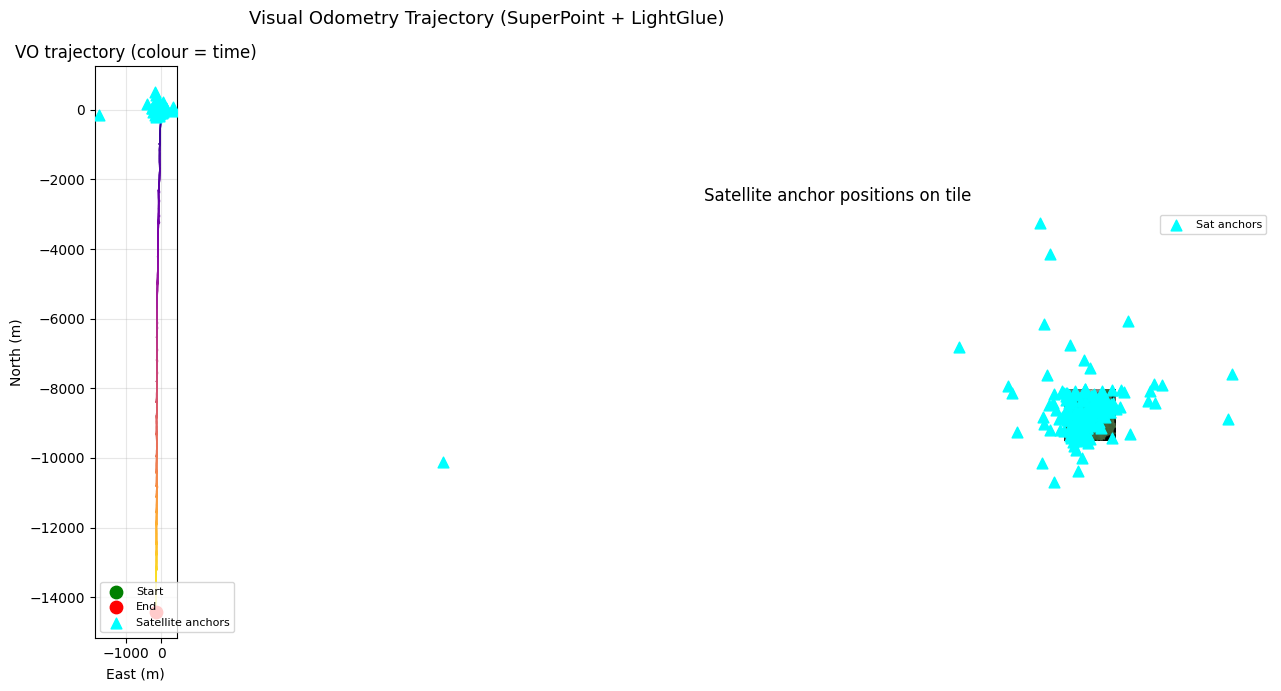

In [21]:
vo_east_m  = [ r['cum_x'] * scale_m_per_px for r in vo_records]
vo_north_m = [-r['cum_y'] * scale_m_per_px for r in vo_records]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
colors = cm.plasma(np.linspace(0, 1, len(vo_east_m)))
for i in range(len(vo_east_m)-1):
    ax.plot(vo_east_m[i:i+2], vo_north_m[i:i+2], color=colors[i], linewidth=1)
ax.scatter(vo_east_m[0],  vo_north_m[0],  c='green', s=80, zorder=5, label='Start')
ax.scatter(vo_east_m[-1], vo_north_m[-1], c='red',   s=80, zorder=5, label='End')
if anchors:
    a0 = anchors[0]
    anc_east  = [(a['est_lon'] - a0['est_lon']) * 111320 * math.cos(math.radians(LAT))
                 for a in anchors]
    anc_north = [(a['est_lat'] - a0['est_lat']) * 111320 for a in anchors]
    ax.scatter(anc_east, anc_north, c='cyan', s=60, zorder=6,
               marker='^', label='Satellite anchors')
ax.set_xlabel('East (m)')
ax.set_ylabel('North (m)')
ax.set_title('VO trajectory (colour = time)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
if sat_tile is not None and anchors:
    ax2.imshow(sat_tile)
    lat_min, lat_max, lon_min, lon_max = bbox_sat
    def gps_to_px(lat, lon):
        x = (lon - lon_min) / (lon_max - lon_min) * IMG_SIZE
        y = (lat_max - lat) / (lat_max - lat_min) * IMG_SIZE
        return x, y
    anc_px = [gps_to_px(a['est_lat'], a['est_lon']) for a in anchors]
    ax2.scatter([p[0] for p in anc_px], [p[1] for p in anc_px],
                c='cyan', s=60, marker='^', zorder=5, label='Sat anchors')
    ax2.set_title('Satellite anchor positions on tile')
    ax2.axis('off')
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Satellite tile\nnot available',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Satellite overlay')

plt.suptitle('Visual Odometry Trajectory (SuperPoint + LightGlue)', fontsize=13)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11 — Fused Trajectory (VO + Satellite Anchors)

Identical to Notebook 2. Piecewise-linear drift correction between consecutive anchors.

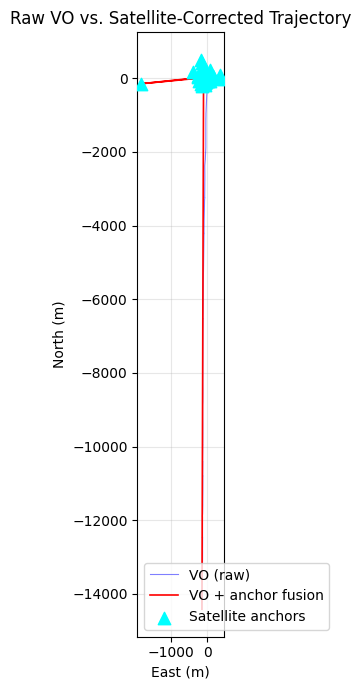

Blue = raw VO  |  Red = corrected by linearly interpolating anchor error


In [22]:
if len(anchors) < 2:
    print('Need >= 2 anchors for fusion -- skipping')
else:
    a0 = anchors[0]
    origin_lat, origin_lon = a0['est_lat'], a0['est_lon']

    def anchor_to_en(a):
        e = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))
        n = (a['est_lat'] - origin_lat) * 111320
        return e, n

    fused_east  = list(vo_east_m)
    fused_north = list(vo_north_m)

    for i in range(len(anchors) - 1):
        ai, aj = anchors[i], anchors[i+1]
        i0 = ai['vo_idx']
        i1 = aj['vo_idx']

        gps_e0, gps_n0 = anchor_to_en(ai)
        gps_e1, gps_n1 = anchor_to_en(aj)

        err_e0 = gps_e0 - vo_east_m[i0]
        err_n0 = gps_n0 - vo_north_m[i0]
        err_e1 = gps_e1 - vo_east_m[i1]
        err_n1 = gps_n1 - vo_north_m[i1]

        for j in range(i0, i1 + 1):
            t = (j - i0) / (i1 - i0) if i1 > i0 else 0
            fused_east[j]  = vo_east_m[j]  + err_e0 + t * (err_e1 - err_e0)
            fused_north[j] = vo_north_m[j] + err_n0 + t * (err_n1 - err_n0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot(vo_east_m, vo_north_m, 'b-', linewidth=0.8, alpha=0.5, label='VO (raw)')
    ax.plot(fused_east, fused_north, 'r-', linewidth=1.2, label='VO + anchor fusion')
    anc_e = [anchor_to_en(a)[0] for a in anchors]
    anc_n = [anchor_to_en(a)[1] for a in anchors]
    ax.scatter(anc_e, anc_n, c='cyan', s=80, zorder=5, marker='^', label='Satellite anchors')
    ax.set_xlabel('East (m)')
    ax.set_ylabel('North (m)')
    ax.set_title('Raw VO vs. Satellite-Corrected Trajectory')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'fused_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Blue = raw VO  |  Red = corrected by linearly interpolating anchor error')

---
## Cell 12 — Summary

Same structure as Notebook 2, plus DL-specific metrics: device, mean LightGlue confidence scores.

In [23]:
total_frames  = len(frame_paths)
duration_s    = total_frames / 15.0
vo_frames     = len(vo_records)
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
failed_pairs  = sum(1 for r in inlier_ratios if r < 0.2)
drift_records = drift_records if 'drift_records' in dir() else []

print('== Deep Learning VO Summary ==============================================')
print(f'Total frames:              {total_frames}  ({duration_s:.1f} s at 15 Hz)')
print(f'VO algorithm:              SuperPoint + LightGlue  '
      f'(max_kp={MAX_KP_VO}, {DOWNSAMPLE_SIZE[0]}x{DOWNSAMPLE_SIZE[1]})')
print(f'Satellite algorithm:       SuperPoint + LightGlue  '
      f'(max_kp={MAX_KP_SAT}, full-res)')
print(f'Device:                    {device}')
if timings_ms:
    mean_ms  = np.mean(timings_ms)
    live_str = 'live-ready' if mean_ms < 1000/15 else 'exceeds budget'
    print(f'Mean per-frame time:       {mean_ms:.1f} ms ({live_str} at 15 Hz)')
    print(f'Effective throughput:      {1000/mean_ms:.0f} fps capability')
if match_scores_vo:
    print(f'Mean LightGlue VO score:   {np.mean(match_scores_vo):.3f}')
print(f'Failed VO pairs (IR<0.2):  {failed_pairs} / {vo_frames-1}  '
      f'({100*failed_pairs/max(1,vo_frames-1):.1f}%)')
print(f'Mean inlier ratio:         {np.mean(inlier_ratios):.3f}')
print(f'Satellite anchors:         {len(anchors)}')
if anchors:
    print(f'Mean anchor LG score:      {np.mean([a["mean_score"] for a in anchors]):.3f}')
if drift_records:
    print(f'Final drift:               {drift_records[-1]["drift_m"]:.1f} m '
          f'after {drift_records[-1]["time_s"]:.1f} s')
    print(f'Drift rate:                '
          f'{drift_records[-1]["drift_m"]/drift_records[-1]["time_s"]:.2f} m/s')
print('==========================================================================')

== Deep Learning VO Summary ==============================================
Total frames:              3430  (228.7 s at 15 Hz)
VO algorithm:              SuperPoint + LightGlue  (max_kp=1024, 640x480)
Satellite algorithm:       SuperPoint + LightGlue  (max_kp=4096, full-res)
Device:                    cuda
Mean per-frame time:       225.2 ms (exceeds budget at 15 Hz)
Effective throughput:      4 fps capability
Mean LightGlue VO score:   1.000
Failed VO pairs (IR<0.2):  0 / 3429  (0.0%)
Mean inlier ratio:         0.997
Satellite anchors:         218
Mean anchor LG score:      1.000
Final drift:               14391.3 m after 228.0 s
Drift rate:                63.12 m/s


---
## Cell 13 — Save Results Log

Same as Notebook 2, with DL-specific fields added to the JSON summary:
- `vo_model`, `matching_model`, `device`, `max_kp_vo`, `max_kp_sat`
- `mean_lg_score_vo`, `mean_lg_score_sat`

Output files are prefixed with `dl_` to avoid overwriting Notebook 2 logs.

In [24]:
import csv, json, datetime

run_ts  = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = RESULTS_DIR

# -- 1. VO frame log ----------------------------------------------------------
vo_log_path = log_dir / f'dl_vo_log_{run_ts}.csv'
vo_fields = ['frame_idx', 'cum_x', 'cum_y', 'cum_yaw',
             'dx', 'dy', 'dyaw', 'good_matches', 'inliers', 'inlier_ratio', 'mean_score']

with open(vo_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=vo_fields)
    w.writeheader()
    for r in vo_records:
        w.writerow({k: r[k] for k in vo_fields})

print(f'VO log:      {vo_log_path}  ({len(vo_records)} rows)')

# -- 2. Anchor log ------------------------------------------------------------
anc_log_path = log_dir / f'dl_anchors_log_{run_ts}.csv'
anc_fields = ['frame_idx', 'vo_idx', 'est_lat', 'est_lon',
              'good_matches', 'inliers', 'mean_score']

with open(anc_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=anc_fields)
    w.writeheader()
    for a in anchors:
        w.writerow({k: a[k] for k in anc_fields})

print(f'Anchors log: {anc_log_path}  ({len(anchors)} rows)')

# -- 3. Summary JSON ----------------------------------------------------------
summary = {
    'run_timestamp':      run_ts,
    'notebook':           'deep_learning_localization',
    'vo_model':           'SuperPoint',
    'matching_model':     'LightGlue',
    'device':             str(device),
    'max_kp_vo':          MAX_KP_VO,
    'max_kp_sat':         MAX_KP_SAT,
    'total_frames':       len(frame_paths),
    'duration_s':         len(frame_paths) / 15.0,
    'sat_match_hz':       SAT_MATCH_HZ,
    'sat_zoom':           SAT_ZOOM,
    'mean_frame_ms':      float(np.mean(timings_ms)) if timings_ms else None,
    'live_ready':         bool(np.mean(timings_ms) < 1000/15) if timings_ms else None,
    'mean_lg_score_vo':   float(np.mean(match_scores_vo)) if match_scores_vo else None,
    'failed_vo_pairs':    int(sum(r['inlier_ratio'] < 0.2 for r in vo_records[1:])),
    'mean_inlier_ratio':  float(np.mean([r['inlier_ratio'] for r in vo_records[1:]])),
    'satellite_anchors':  len(anchors),
    'mean_lg_score_sat':  float(np.mean([a['mean_score'] for a in anchors])) if anchors else None,
    'scale_m_per_px':     scale_m_per_px,
    'final_drift_m':      drift_records[-1]['drift_m'] if drift_records else None,
    'drift_rate_m_per_s': (drift_records[-1]['drift_m'] / drift_records[-1]['time_s']
                           if drift_records and drift_records[-1]['time_s'] > 0 else None),
    'plots_saved':        [str(p.name) for p in RESULTS_DIR.glob('*.png')],
}

summary_path = log_dir / f'dl_summary_{run_ts}.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Summary:     {summary_path}')
print()
for k, v in summary.items():
    if v is not None:
        print(f'  {k:<30} {v}')

VO log:      /content/results/nb3/dl_vo_log_20260623_085216.csv  (3430 rows)
Anchors log: /content/results/nb3/dl_anchors_log_20260623_085216.csv  (218 rows)
Summary:     /content/results/nb3/dl_summary_20260623_085216.json

  run_timestamp                  20260623_085216
  notebook                       deep_learning_localization
  vo_model                       SuperPoint
  matching_model                 LightGlue
  device                         cuda
  max_kp_vo                      1024
  max_kp_sat                     4096
  total_frames                   3430
  duration_s                     228.66666666666666
  sat_match_hz                   1.0
  sat_zoom                       19
  mean_frame_ms                  225.22599138612088
  live_ready                     False
  mean_lg_score_vo               1.0
  failed_vo_pairs                0
  mean_inlier_ratio              0.9971848891505265
  satellite_anchors              218
  mean_lg_score_sat              1.0
  scale_m_per

---
## Cell 14 — Visual Verification: Drone Frame vs Satellite at Estimated Coordinates

For a sample of anchor frames, shows the drone image alongside the satellite view at the estimated GPS position.

- **Left**: drone camera frame
- **Middle**: original satellite tile used for matching, with the estimated drone position marked (red crosshair)
- **Right** *(only if `MAPS_API_KEY` is set)*: fresh satellite tile fetched and centred at the estimated coordinates — the strongest sanity check: the terrain visible in the drone frame should match what's in the centre of this tile

Tiles fetched here are cached to `data/` with a `sat_verify_` prefix so re-runs are instant.

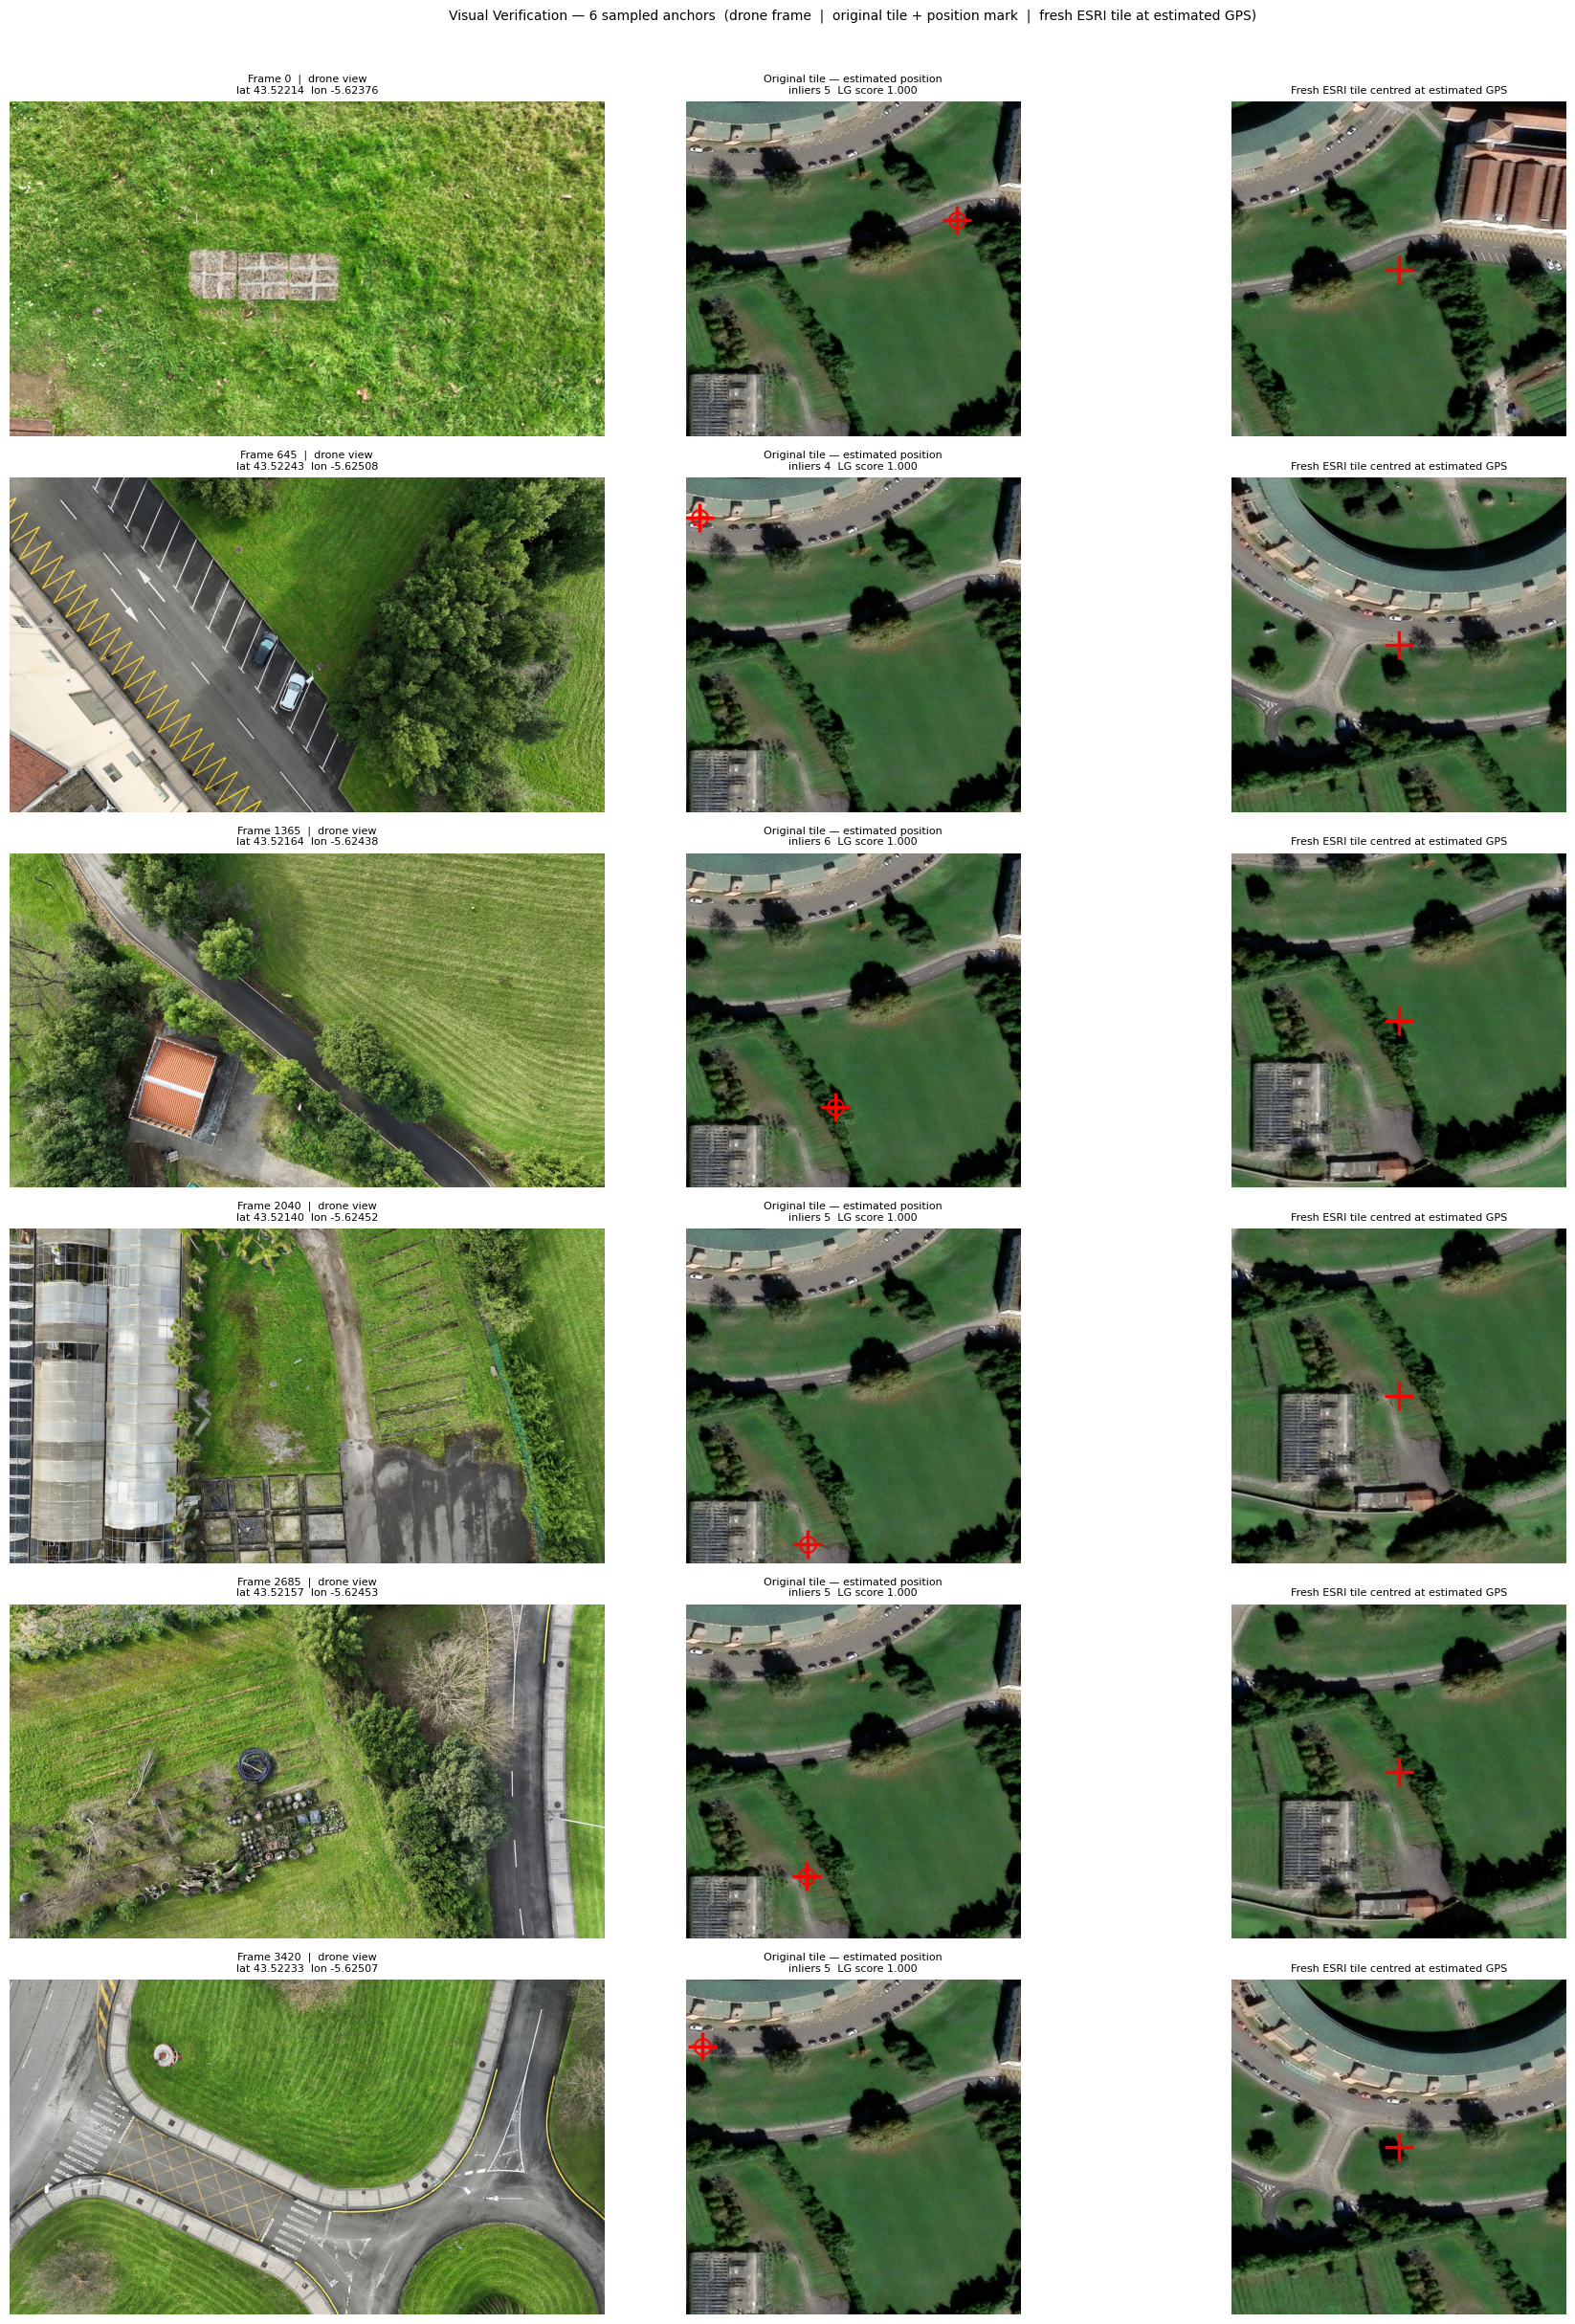

Saved: /content/results/nb3/visual_verification.png


In [25]:
N_VERIFY = 6  # number of anchor frames to compare (evenly spaced across all anchors)

if not anchors:
    print('No anchors to visualise.')
elif sat_tile is None:
    print('No satellite tile loaded — run Cell 6 first.')
else:
    idxs   = np.linspace(0, len(anchors) - 1, min(N_VERIFY, len(anchors)), dtype=int)
    sample = [anchors[i] for i in idxs]

    lat_min, lat_max, lon_min, lon_max = bbox_sat
    tile_h, tile_w = sat_tile.shape[:2]

    def _gps_to_sat_px(lat, lon):
        x = (lon - lon_min) / (lon_max - lon_min) * tile_w
        y = (lat_max - lat) / (lat_max - lat_min) * tile_h
        return x, y

    fig, axes = plt.subplots(len(sample), 3, figsize=(18, 4 * len(sample)))
    if len(sample) == 1:
        axes = [axes]

    for row, anchor in enumerate(sample):
        est_lat = anchor['est_lat']
        est_lon = anchor['est_lon']

        # Left — drone frame
        drone_rgb = cv2.cvtColor(cv2.imread(str(frame_paths[anchor['frame_idx']])),
                                  cv2.COLOR_BGR2RGB)
        axes[row][0].imshow(drone_rgb)
        axes[row][0].set_title(
            f'Frame {anchor["frame_idx"]}  |  drone view\n'
            f'lat {est_lat:.5f}  lon {est_lon:.5f}', fontsize=8)
        axes[row][0].axis('off')

        # Middle — original satellite tile with estimated position marked
        px, py = _gps_to_sat_px(est_lat, est_lon)
        axes[row][1].imshow(sat_tile)
        axes[row][1].plot(px, py, 'r+', markersize=22, markeredgewidth=2.5)
        axes[row][1].plot(px, py, 'ro', markersize=12, fillstyle='none', markeredgewidth=1.5)
        axes[row][1].set_title(
            f'Original tile — estimated position\n'
            f'inliers {anchor["inliers"]}  '
            f'LG score {anchor.get("mean_score", 0):.3f}', fontsize=8)
        axes[row][1].axis('off')

        # Right — fresh ESRI tile centred at estimated GPS
        fname = DATA_DIR / f'sat_verify_{est_lat:.5f}_{est_lon:.5f}_z{SAT_ZOOM}.png'
        fresh = None
        if fname.exists():
            fresh = np.array(Image.open(fname).convert('RGB'))
        else:
            try:
                fresh = fetch_esri_tile(est_lat, est_lon, IMG_SIZE, SAT_ZOOM)
                Image.fromarray(fresh).save(fname)
            except Exception as e:
                print(f'  ESRI tile fetch failed (frame {anchor["frame_idx"]}): {e}')

        if fresh is not None:
            cx, cy = fresh.shape[1] / 2, fresh.shape[0] / 2
            axes[row][2].imshow(fresh)
            axes[row][2].plot(cx, cy, 'r+', markersize=22, markeredgewidth=2.5)
            axes[row][2].set_title('Fresh ESRI tile centred at estimated GPS', fontsize=8)
        else:
            axes[row][2].text(0.5, 0.5, 'Fetch failed', ha='center', va='center',
                              transform=axes[row][2].transAxes, fontsize=10)
        axes[row][2].axis('off')

    plt.suptitle(
        f'Visual Verification — {len(sample)} sampled anchors  '
        f'(drone frame  |  original tile + position mark  |  fresh ESRI tile at estimated GPS)',
        fontsize=10, y=1.01)
    plt.tight_layout()
    out_path = RESULTS_DIR / 'visual_verification.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')

In [ ]:
import shutil, os

drive_results = '/content/drive/MyDrive/capstone-dronomy/results/nb3'
os.makedirs(drive_results, exist_ok=True)
shutil.copytree(str(RESULTS_DIR), drive_results, dirs_exist_ok=True)
print(f'Results saved to Drive: {drive_results}')
print(os.listdir(drive_results))